#**CHAPTER 1.DIFFUSION, TRANSFORMERS AND SYNTHETIC DATA GENERATION**
---

##REFERENCE

https://chatgpt.com/share/69b17374-4efc-8012-9fa3-65b460e2c149

##0.CONTEXT

**Introduction**

This notebook is designed as a mechanics-first introduction to diffusion models, with a particular emphasis on how those models can be understood, implemented, and interpreted in a financial context. The subject of diffusion has become increasingly important because it offers a different generative paradigm from the one most people first encounter through autoregressive language models. In an autoregressive model, generation proceeds one step at a time by predicting the next token based on prior context. In a diffusion model, by contrast, generation is framed as a gradual process of corruption and reconstruction. One begins with clean structure, progressively injects noise, and then trains a model to reverse that degradation. The intellectual appeal of this framework is that it transforms generation into an iterative denoising problem. The practical appeal is that it often produces stable training objectives, flexible conditioning mechanisms, and elegant connections to probability, statistics, stochastic processes, and modern deep learning.

For students and practitioners in finance, this topic is especially valuable because financial data is noisy by nature. Markets are not pristine objects. Returns, volatility, cross-sectional features, regime indicators, and scenario paths all contain randomness, partial structure, latent patterns, and occasional discontinuities. A modeling framework built around learning the relationship between signal and noise is therefore not merely an abstract machine learning curiosity. It is conceptually aligned with the nature of the domain itself. Finance often asks us to distinguish persistent structure from transient disturbance, long-run information from short-run fluctuations, and scenario-relevant variation from irrelevant randomness. Diffusion models provide a compelling formal framework for that distinction.

This notebook has been intentionally designed to be synthetic, compact, and pedagogical. It does not depend on external data sources, APIs, or large infrastructure. That design choice is not accidental. When learning a technically rich concept such as diffusion, real-world data can easily distract from the core mechanism. Market microstructure issues, survivorship bias, timestamp handling, missing values, vendor conventions, and data licensing can overwhelm the lesson before the student even reaches the modeling stage. By using synthetic data, the notebook isolates the model mechanics. The learner can focus on what the forward process is doing, what the reverse process is learning, how the training loss behaves, and how generated paths compare to the reference distribution. In other words, the notebook aims to teach the architecture and the mathematical intuition before adding the complexity of institutional data environments.

A second important feature of the notebook is that it uses a transformer as the denoising backbone. This matters because one of the central educational goals of the project is to build a bridge between traditional diffusion models from the image domain and diffusion ideas as they move toward sequence models, discrete token models, and eventually language-model-related applications. In the original image-oriented literature, the denoising network is often a U-Net. That architecture is highly effective for grid-like spatial data because it combines local feature extraction with multiscale representations. In this notebook, however, the data are one-dimensional sequences, and the denoiser is a small transformer. This shift is pedagogically useful because it shows that the diffusion framework is not tied to a particular backbone. The essence of diffusion is not the U-Net itself. The essence is the probabilistic process of noising and denoising. Once that point is understood, the learner can begin to see how the same generative logic might be applied to time series, tabular data, masked token sequences, and financial language modeling.

The notebook begins with setup and configuration because rigor in technical work starts with clarity of environment. Dependencies, device choice, random seeds, and modular parameter settings may look mundane at first glance, but they are foundational for reproducibility and disciplined experimentation. In finance especially, the difference between a toy result and a defensible result often begins with whether the workflow can be repeated consistently. Even in a lightweight teaching notebook, this principle matters. The code therefore establishes a deterministic frame before any data or model is introduced.

The synthetic data generation section is one of the most important pedagogical stages. The goal is not to create a perfect simulation of markets. That would be unrealistic and, for a first notebook, counterproductive. Instead, the goal is to create return-like sequences that contain several properties that are intuitively familiar to finance students: oscillation, trend, nonconstant volatility, and occasional shocks. These ingredients create a data environment that is rich enough to make the generative task meaningful, while still being simple enough that the learner can mentally track what is happening. The synthetic series are normalized path by path so that the model does not become preoccupied with trivial scale effects. This choice also helps the student see the model as learning shape, dynamics, and distributional structure rather than memorizing magnitude alone.

Once the data are available, the notebook introduces the Gaussian forward process. This is the heart of continuous diffusion. Clean data are progressively transformed into noisy versions according to a schedule. At small time indices, the corrupted sample still resembles the original. At larger time indices, much of the structure has been destroyed. The forward process itself is simple enough to state compactly, but its conceptual importance is enormous. It defines the supervised learning problem indirectly. The model is not asked to generate a sequence from scratch in one leap. Instead, it is repeatedly asked to predict the noise that was added to partially corrupted data. In learning that prediction across many noise levels, the model acquires the ability to move step by step from random noise back toward structured samples.

The time embedding stage is also central. A denoiser must know not only the corrupted input, but also the level of corruption. Without that information, the same noisy sequence could correspond to very different reconstruction tasks depending on whether the process is early or late in the diffusion chain. The sinusoidal time embedding provides that conditioning in a way that is compact, elegant, and widely useful across neural architectures. It converts timestep information into a continuous representation that the model can integrate with sequence features.

The transformer denoiser then becomes the notebook’s main learning engine. The transformer is used here in a deliberately modest form, with a small parameter count and limited depth so that the notebook remains runnable on accessible hardware. Yet even this compact model demonstrates a powerful idea: attention-based architectures can act as denoisers over sequences. Instead of predicting the next token in an autoregressive chain, the transformer learns to infer the latent clean structure hidden inside a noisy sequence. This reframing is one of the major conceptual steps needed for understanding how diffusion ideas may interact with sequence modeling more broadly, including in finance and eventually in language-oriented settings.

The training loss is straightforward but conceptually rich. Mean squared error between true noise and predicted noise may seem like an ordinary regression objective, but in the diffusion context it is linked to a much deeper probabilistic interpretation. The model is not merely regressing arbitrary targets. It is learning a vector field that approximates how corrupted observations should be moved back toward regions of higher data likelihood. This is part of the reason diffusion models connect naturally to score matching and stochastic differential equation perspectives. In a first notebook, however, the learner does not need every theoretical refinement immediately. What matters is to see that minimizing denoising error across many timesteps gives rise to a generative model.

The later cells move from training into interpretation. The training curves show whether the model is learning. The forward noising visualization shows how the corruption schedule gradually erodes structure. The reverse sampling procedure demonstrates how one can start from pure noise and reconstruct candidate sequences through repeated denoising steps. The generated return paths reveal whether the model has captured plausible shapes and diversity rather than degenerating into repetitive or collapsed samples. The histogram comparison offers a first distributional diagnostic, and the denoising trajectory visualization gives the student a dynamic picture of generation itself. These are not merely cosmetic plots. They are instruments of model understanding.

Overall, the notebook should be read as both a technical exercise and a conceptual bridge. It introduces diffusion in a compact continuous setting while preparing the learner for more advanced topics such as masked diffusion for discrete sequences, conditional scenario generation, tabular synthesis, imputation, and eventually diffusion-inspired methods for financial language data. Its ambition is not to solve finance. Its ambition is more modest and more important: to teach a new modeling paradigm in a form that is understandable, reproducible, and intellectually connected to real financial applications. If the notebook works well, the learner should leave with more than code that runs. The learner should leave with a mental model of what diffusion is, why iterative denoising is a meaningful generative principle, how transformers can participate in that framework, and why this matters for the future of finance-oriented machine learning.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 Explanation**

This first cell establishes the computational environment for the notebook. Even though it looks simple, it is one of the most important cells because it defines the technical foundation on which everything else depends. The cell imports the core libraries used throughout the notebook. These include numerical tools, plotting tools, the PyTorch deep learning framework, dataset and dataloader utilities, and a progress bar package for monitoring training. Without this initial setup, the later cells would have no common environment in which to operate.

A major purpose of this cell is to ensure that the notebook is reproducible. Reproducibility means that if the same notebook is run again under the same conditions, it should produce approximately the same results. To support that goal, the cell sets random seeds for Python, NumPy, and PyTorch. Machine learning experiments often contain many random elements, including parameter initialization, noise generation, and minibatch ordering. If these sources of randomness are not controlled, two runs of the same notebook may behave differently, making it harder to understand whether changes in outcomes are due to genuine improvements or merely random chance. By fixing the seeds, this cell reduces that ambiguity.

The cell also determines which hardware device will be used. If a GPU is available, the notebook can use it to accelerate training. If not, the notebook falls back to the CPU. This step is important because the rest of the notebook must know where tensors and models should live. PyTorch requires consistency in device placement. If the model is on the GPU but the data are on the CPU, errors will occur. This first cell therefore makes the hardware decision explicit and prints the result for transparency.

Pedagogically, this cell teaches that machine learning work begins with disciplined setup rather than with the model alone. Students sometimes want to jump immediately to the neural network, but that can create confusion later when basic environment issues arise. A well-structured notebook starts by making its computational assumptions visible. In that sense, this cell introduces the professional habit of building a controlled experiment before attempting analysis or training.

In [1]:
# =========================================================
# CELL 1 — Setup & Imports
# =========================================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


##2.CONFIGURTATION

###2.1.OVERVIEW

**Cell 2 Explanation**

This cell defines the main configuration object for the notebook. Instead of scattering numerical settings across many parts of the code, the notebook gathers the most important parameters into one place. This is a very good practice because it makes the experiment easier to read, easier to modify, and easier to reproduce. When someone wants to know the sequence length, batch size, number of epochs, learning rate, diffusion steps, or transformer size, they can find all of that information here.

The configuration includes settings related to the data, the training process, and the model architecture. For the data, it specifies things such as how long each time series should be and how many synthetic examples should be generated for training and validation. For training, it sets values such as the batch size, learning rate, and number of training epochs. For the model, it controls the transformer dimension, number of attention heads, number of layers, feedforward expansion, and dropout. All of these are central choices that shape the notebook’s runtime and behavior.

One reason this cell is pedagogically valuable is that it helps students understand that machine learning models are not just equations. They are systems defined by many design choices. Two notebooks can implement the same core idea but behave very differently because of different parameter settings. By making those settings explicit, this cell encourages a more experimental mindset. The learner sees that a model is the result of a controlled configuration, not just a black-box command.

This cell also promotes modular thinking. Because the parameters are centralized, it becomes easy to change the scale of the experiment later. A student could increase the number of epochs, shorten the sequence length, or reduce the model dimension without rewriting the whole notebook. That flexibility is particularly useful in educational settings, where one often wants to trade off between runtime and model quality. In summary, this cell organizes the notebook into a coherent and modifiable experiment rather than a collection of disconnected code fragments.

###2.2.CODE AND IMPLEMENTATION

In [4]:
# =========================================================
# CELL 2 — Project Configuration
# =========================================================

@dataclass
class Config:
    seq_len: int = 64
    train_size: int = 6000
    val_size: int = 1000
    batch_size: int = 128
    epochs: int = 12
    lr: float = 2e-4

    diffusion_steps: int = 100

    model_dim: int = 96
    num_heads: int = 4
    num_layers: int = 4
    ff_mult: int = 4
    dropout: float = 0.1

    num_workers: int = 2

cfg = Config()
print(cfg)

Config(seq_len=64, train_size=6000, val_size=1000, batch_size=128, epochs=12, lr=0.0002, diffusion_steps=100, model_dim=96, num_heads=4, num_layers=4, ff_mult=4, dropout=0.1, num_workers=2)


##3.SYNTHETIC DATA GENERATOR

###3.1.OVERVIEW

**Cell 3 Explanation**

This cell creates the synthetic financial time-series dataset used by the model. The notebook does not download real market data. Instead, it generates artificial sequences that are designed to resemble some broad behaviors seen in financial returns. This is a crucial design choice because it allows the student to focus on the mechanics of diffusion modeling without being distracted by data vendor issues, missing values, asset selection, or institutional data cleaning problems.

The generated series combine several simple ingredients. One ingredient is sinusoidal structure, which creates oscillation over time. Another is trend, which allows some sequences to drift upward or downward. A third is changing volatility, which makes the noise level vary across the sequence instead of remaining constant. A fourth is random shocks, which introduce occasional abrupt movements. None of these ingredients is meant to perfectly reproduce real markets. Instead, together they create sequences that are visually and statistically richer than plain white noise.

At the end of generation, each sequence is normalized. This means that its mean is shifted and its scale is adjusted so that the model focuses on structure rather than on raw magnitude differences. This is helpful in a pedagogical notebook because it reduces unnecessary scale variation and makes learning more stable. It also makes the resulting paths easier to compare visually.

This cell is important because generative models need something meaningful to learn from. If the data were too simple, the model would not teach us much. If the data were too realistic and messy, the lesson could become confusing. This synthetic middle ground is ideal for a first notebook. It gives the learner an environment in which the model has something nontrivial to capture, while still allowing the logic of the data-generating process to remain understandable.

###3.2.CODE AND IMPLEMENTATION

In [5]:
# =========================================================
# CELL 3 — Synthetic Financial Time-Series Generator
# =========================================================
# We simulate stock-like return paths using mixtures of:
# - sinusoidal structure
# - trend
# - volatility clustering proxy
# - random shocks

def generate_synthetic_return_series(
    n_samples: int,
    seq_len: int,
    shock_prob: float = 0.06
):
    data = []

    t = np.linspace(0, 2 * np.pi, seq_len)

    for _ in range(n_samples):
        amp1 = np.random.uniform(0.4, 1.2)
        amp2 = np.random.uniform(0.1, 0.6)
        freq1 = np.random.uniform(0.8, 2.5)
        freq2 = np.random.uniform(2.0, 5.0)
        phase1 = np.random.uniform(0, 2 * np.pi)
        phase2 = np.random.uniform(0, 2 * np.pi)

        trend = np.random.uniform(-0.03, 0.03) * np.arange(seq_len)

        base = (
            amp1 * np.sin(freq1 * t + phase1) +
            amp2 * np.sin(freq2 * t + phase2)
        )

        # Heteroskedastic noise proxy
        vol_profile = 0.08 + 0.10 * (np.sin(t + np.random.uniform(0, 2*np.pi)) ** 2)
        noise = np.random.normal(0, vol_profile, size=seq_len)

        # Random shocks
        shocks = np.zeros(seq_len)
        for i in range(seq_len):
            if np.random.rand() < shock_prob:
                shocks[i] += np.random.normal(0, 0.7)

        series = base + trend + noise + shocks

        # Normalize each path
        series = (series - series.mean()) / (series.std() + 1e-6)
        data.append(series.astype(np.float32))

    return np.stack(data)

train_data = generate_synthetic_return_series(cfg.train_size, cfg.seq_len)
val_data   = generate_synthetic_return_series(cfg.val_size, cfg.seq_len)

print("Train shape:", train_data.shape)
print("Val shape:", val_data.shape)

Train shape: (6000, 64)
Val shape: (1000, 64)


##4.DATASET AND VISUALIZATION

###4.1.OVERVIEW

**Cell 4 Explanation**

This cell wraps the synthetic data into a PyTorch dataset and prepares dataloaders for training and validation. In addition, it visualizes a few example series so that the student can inspect the structure of the synthetic data before any model training begins. This combination of data engineering and exploratory visualization makes the cell especially important.

The custom dataset class is simple. It stores the generated array and defines how to access each individual sequence. Each item is returned with an extra dimension so that the shape becomes suitable for the model, which expects a sequence with a feature dimension. Even though the data are one-dimensional in substance, neural networks often require explicit feature axes. This detail helps students appreciate that deep learning code often involves careful shape management.

The dataloaders then handle batching. Instead of feeding the full dataset into the model at once, the notebook splits it into minibatches. This is more memory efficient and is the standard way to train neural networks. The training dataloader shuffles the data so that the model does not always see sequences in the same order. The validation dataloader does not shuffle because evaluation does not require randomized ordering. These are standard professional conventions, and the cell exposes them in a clean way.

The visualization at the end of the cell is pedagogically valuable because it grounds the abstract idea of “synthetic data” in something the learner can see. By plotting several sequences together, the notebook shows that the generated paths have diversity, oscillation, variability, and occasional irregularities. This visual check helps the learner build intuition about what the model is expected to reproduce later. Before training a generative model, one should always know what the reference data look like. This cell ensures that the notebook does not treat the dataset as an invisible object.

###4.2.CODE AND IMPLEMENTATION

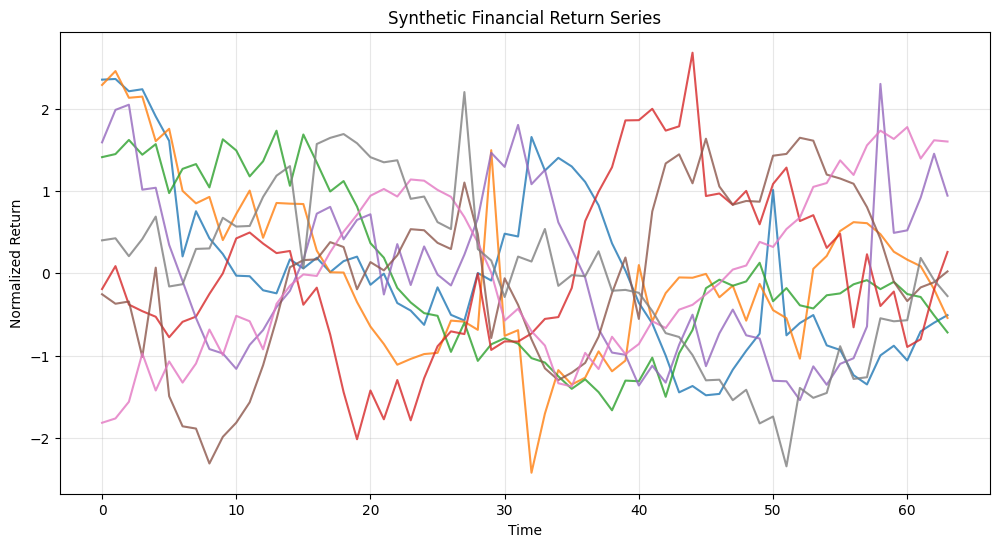

In [6]:
# =========================================================
# CELL 4 — Dataset and Visualization
# =========================================================

class TimeSeriesDataset(Dataset):
    def __init__(self, array: np.ndarray):
        self.x = torch.tensor(array, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Shape: [seq_len, 1]
        return self.x[idx].unsqueeze(-1)

train_ds = TimeSeriesDataset(train_data)
val_ds = TimeSeriesDataset(val_data)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True
)

# Visualize examples
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.plot(train_data[i], alpha=0.8)
plt.title("Synthetic Financial Return Series")
plt.xlabel("Time")
plt.ylabel("Normalized Return")
plt.grid(True, alpha=0.3)
plt.show()

##5.DIFFUSION SCHECULE UTILITIES

###5.1.OVERVIEW

**Cell 5 Explanation**

This cell introduces the diffusion schedule and the core utilities for the forward noising process. It is one of the conceptual centers of the notebook because diffusion begins with a rule for how clean data are gradually corrupted over time. Without this cell, there would be no diffusion process to learn.

The first part of the cell defines a linear beta schedule. The beta values determine how much noise is introduced at each timestep. Small values correspond to gentle corruption, while larger values increase the amount of randomness. From these betas, the cell derives other useful quantities such as the alphas and the cumulative products of alphas. These derived terms are important because they let the notebook express the noisy version of a sample at any timestep directly, without having to simulate each intermediate step one by one.

The utility function called extract is a technical helper. It pulls the correct schedule values for each sample in a batch, because different samples may be assigned different timesteps during training. It then reshapes those values so they can be broadcast properly across the sequence dimensions. This may look like a small implementation detail, but it is essential for making batch computation work correctly.

The function q_sample is the most pedagogically important part of the cell. It generates a noisy version of a clean sample. The function combines the original sequence and a randomly drawn noise tensor according to the diffusion schedule. This is the mechanism through which the notebook creates supervised learning examples for the denoiser. The model will later see the noisy sequence and try to predict the noise that was added.

In educational terms, this cell teaches that diffusion is not magic. It starts from a very explicit corruption rule. Once the student understands how data are degraded, it becomes easier to understand what the model is trying to reverse.

###5.2.CODE AND IMPLEMENTATION

In [7]:
# =========================================================
# CELL 5 — Diffusion Schedule Utilities
# =========================================================
# We use a standard DDPM-style Gaussian forward process.

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(cfg.diffusion_steps).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)

sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - torch.cat([torch.tensor([1.0], device=device), alpha_bars[:-1]])) / (1.0 - alpha_bars)

def extract(a, t, x_shape):
    """
    Extract values from a 1D schedule tensor 'a' at indices t and reshape for broadcasting.
    """
    batch_size = t.shape[0]
    out = a.gather(0, t)
    return out.view(batch_size, *((1,) * (len(x_shape) - 1)))

def q_sample(x0, t, noise=None):
    """
    Forward noising:
    x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps
    """
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ab = extract(sqrt_alpha_bars, t, x0.shape)
    sqrt_omb = extract(sqrt_one_minus_alpha_bars, t, x0.shape)
    return sqrt_ab * x0 + sqrt_omb * noise

##6.TIME EMBEDDING

###6.1.OVERVIEW

**Cell 6 Explanation**

This cell defines the time embedding mechanism. In a diffusion model, the denoiser must know not only the noisy input but also the timestep at which that input was produced. The reason is simple: a slightly noisy sequence and a heavily noisy sequence require very different reconstruction behavior. The model cannot infer the intended level of corruption from the input alone with full reliability. It needs to be told where in the diffusion process it is operating.

The cell uses sinusoidal embeddings to represent time. This idea is widely used in modern deep learning because it converts an integer index into a continuous vector that can be processed by the neural network. Different dimensions of the embedding oscillate at different frequencies, allowing the timestep to be encoded in a rich but compact form. The result is that the model receives a continuous signal about the diffusion step rather than just a raw integer.

Pedagogically, this cell is important because it shows how conditioning information is injected into neural architectures. Students often think of neural networks as taking only the obvious input, such as a sequence or an image. But many models also require contextual signals such as time, class labels, scenario types, or other metadata. This cell demonstrates one elegant way to provide such context.

The time embedding is especially relevant in diffusion because the same denoiser is reused across many different stages of the reverse process. Rather than training a separate network for each timestep, the notebook trains one network that adapts its behavior depending on the embedded time information. This is efficient and conceptually powerful. It means the network learns a family of denoising tasks, all coordinated through the timestep representation. This cell therefore teaches both a specific implementation tool and a broader lesson about conditional modeling.

###6.2.CODE AND IMPLEMENTATION

In [8]:
# =========================================================
# CELL 6 — Time Embedding
# =========================================================

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor):
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / max(half_dim - 1, 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb

##7.MINIMAL TRANSFORMER DENOISER

###7.1.OVERVIEW

**Cell 7 Explanation**

This cell defines the main neural network of the notebook: the transformer denoiser. This model receives a noisy sequence and a timestep, and it outputs a prediction of the noise component. The denoiser is the heart of the learning process because it is the part of the notebook that actually learns how to reverse the forward corruption.

The architecture begins by projecting the one-dimensional input values into a higher-dimensional latent space. Neural networks usually work better when inputs are transformed into richer internal representations. The model also includes learned positional embeddings so that it can distinguish different locations in the sequence. This matters because a transformer processes sets of token-like elements, and without positional information it would not know whether a value appears early or late in the time series.

The timestep information is then transformed through a small multilayer perceptron and added to the sequence representation. This step combines the corruption-level signal with the sequence features, allowing the model to adapt its denoising behavior depending on how noisy the input is. After that, the sequence is passed through several transformer encoder layers. These layers use attention to relate each time position to the others. This allows the model to reconstruct local and global structure rather than treating each position independently.

Finally, the network projects the internal representation back down to the original input dimension so that it can output a noise prediction for each time point. The cell also counts the model parameters to verify that the architecture remains small enough for the runtime constraints.

This cell is pedagogically significant because it demonstrates that the denoising task can be handled by a transformer, not only by image-oriented architectures. It helps the student see diffusion as a general framework and the neural network as a replaceable backbone adapted to the structure of the data.

###7.2.CODE AND IMPLEMENTATION

In [9]:
# =========================================================
# CELL 7 — Minimal Transformer Denoiser
# =========================================================
# Input: noisy sequence x_t of shape [B, L, 1]
# Output: predicted noise epsilon of shape [B, L, 1]

class TransformerDenoiser(nn.Module):
    def __init__(
        self,
        seq_len: int,
        input_dim: int = 1,
        model_dim: int = 96,
        num_heads: int = 4,
        num_layers: int = 4,
        ff_mult: int = 4,
        dropout: float = 0.1
    ):
        super().__init__()
        self.seq_len = seq_len
        self.model_dim = model_dim

        self.input_proj = nn.Linear(input_dim, model_dim)
        self.pos_emb = nn.Parameter(torch.randn(1, seq_len, model_dim) * 0.02)

        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(model_dim),
            nn.Linear(model_dim, model_dim * 2),
            nn.GELU(),
            nn.Linear(model_dim * 2, model_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=model_dim * ff_mult,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(model_dim)
        self.out_proj = nn.Linear(model_dim, input_dim)

    def forward(self, x, t):
        """
        x: [B, L, 1]
        t: [B]
        """
        h = self.input_proj(x)
        h = h + self.pos_emb[:, :h.size(1), :]

        t_emb = self.time_mlp(t).unsqueeze(1)  # [B, 1, D]
        h = h + t_emb

        h = self.encoder(h)
        h = self.norm(h)
        return self.out_proj(h)

model = TransformerDenoiser(
    seq_len=cfg.seq_len,
    input_dim=1,
    model_dim=cfg.model_dim,
    num_heads=cfg.num_heads,
    num_layers=cfg.num_layers,
    ff_mult=cfg.ff_mult,
    dropout=cfg.dropout
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Model parameters: 491,137


/tmp/ipykernel_12074/2332169370.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


##8.TRAINING LOSS

###8.1.OVERVIEW

**Cell 8 Explanation**

This cell defines the training objective and the optimizer. The training objective is the rule that tells the model how well it is performing and what it should improve. In this notebook, the objective is the standard diffusion loss based on mean squared error between the true noise and the model’s predicted noise.

The function begins by choosing a random timestep for each sequence in the batch. This is important because the model must learn to denoise across the entire diffusion process, not just at one fixed stage. A random noise tensor is then generated, and the clean sequence is corrupted using the forward process defined earlier. The noisy sequence and its timestep are passed into the model, which produces a noise prediction. The loss is then computed by comparing this prediction to the actual noise that was added.

Conceptually, this is a very elegant training setup. The notebook always knows the correct answer because it created the noise itself. That makes the denoising problem supervised, even though the broader goal is generative modeling. This is one of the most beautiful aspects of diffusion training: generation emerges from repeatedly solving a well-defined local prediction problem.

The cell also initializes the optimizer, which is the algorithm used to update the neural network parameters during training. In this case, AdamW is used, which is a common and effective choice for transformer-based models. The optimizer translates the loss signal into parameter adjustments.

Pedagogically, this cell shows the student how the abstract mathematics of diffusion becomes an actual learning signal. It also reinforces the idea that a generative model can be trained through a sequence of ordinary supervised denoising tasks rather than through direct sample generation during training.

###8.2.CODE AND IMPLEMENTATION

In [10]:
# =========================================================
# CELL 8 — Training Loss
# =========================================================
# Standard DDPM epsilon-prediction loss:
# L = E ||eps - eps_theta(x_t, t)||^2

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr)

def diffusion_loss(model, x0):
    B = x0.size(0)
    t = torch.randint(0, cfg.diffusion_steps, (B,), device=x0.device).long()
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    noise_pred = model(xt, t)
    return F.mse_loss(noise_pred, noise)

##9.TRAINING LOOP

###9.1.0VERVIEW

**Cell 9 Explanation**

This cell runs the main training loop. Up to this point, the notebook has defined the data, the diffusion process, the time embedding, the denoiser, and the loss. This cell is where those components finally interact over multiple epochs so that the model can learn.

The cell contains an evaluation function that computes the average validation loss without updating the model. This separation between training and evaluation is good practice because it allows the student to monitor performance on held-out data. During training, the model sees batches from the training set, computes the diffusion loss, backpropagates gradients, clips gradient norms for stability, and updates its parameters using the optimizer. The process is repeated across all batches and across multiple epochs.

The progress bar provides real-time feedback on the current batch loss, which makes the training process easier to follow. After each epoch, the notebook computes both the average training loss and the validation loss and stores them for later plotting. These saved losses will help the student inspect whether the model is learning consistently.

Pedagogically, this cell is important because it translates the static definitions of earlier cells into a dynamic learning process. Students often understand model components separately but struggle to see how they come together operationally. This cell shows that training is an iterative loop in which the model repeatedly sees noisy examples, tries to predict the added noise, receives corrective feedback, and gradually improves.

This cell also teaches that model development is not only about architecture design. Optimization behavior matters. A model that is well designed but poorly trained will still fail. By making the training loop explicit, the notebook helps the learner understand the practical side of deep learning experimentation.

###9.2.CODE AND IMPLEMENTATION

In [11]:
# =========================================================
# CELL 9 — Training Loop
# =========================================================

def evaluate(model, loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for x0 in loader:
            x0 = x0.to(device)
            loss = diffusion_loss(model, x0)
            losses.append(loss.item())
    return float(np.mean(losses))

train_losses = []
val_losses = []

for epoch in range(cfg.epochs):
    model.train()
    batch_losses = []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
    for x0 in pbar:
        x0 = x0.to(device)

        optimizer.zero_grad()
        loss = diffusion_loss(model, x0)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        batch_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = float(np.mean(batch_losses))
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train={train_loss:.6f}, val={val_loss:.6f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/12:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1: train=0.830049, val=0.741093


Epoch 2/12:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2: train=0.741188, val=0.733479


...

Epoch 10: train=0.728551, val=0.722163


Epoch 11/12:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 11: train=0.724597, val=0.723074


Epoch 12/12:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 12: train=0.726896, val=0.735294


##10.TRAINING CURVES

###10.1.OVERVIEW

**Cell 10 Explanation**

This cell visualizes the training and validation losses across epochs. At first glance, it may seem like a simple plotting step, but it plays an important role in understanding whether the model is actually learning. Machine learning is not just about writing code that runs. It is about observing whether the optimization process behaves sensibly.

The plot shows two curves. The training loss reflects how well the model is fitting the batches it learns from directly. The validation loss reflects how well the model performs on separate data that were not used for parameter updates. If both losses generally decrease, that suggests the model is learning useful structure rather than simply failing to optimize. If the training loss decreases while the validation loss rises sharply, that can indicate overfitting. If neither curve improves, the model may be underpowered, poorly configured, or incorrectly implemented.

Pedagogically, this cell helps the student connect the abstract idea of “learning” to observable evidence. It also encourages the habit of diagnosing models through metrics instead of relying only on final output samples. In generative modeling especially, students can be tempted to judge a model entirely by a few visually pleasing outputs. But proper training diagnostics are just as important as qualitative inspection.

This cell also reinforces the importance of keeping records during training. Because the losses were stored in the previous cell, they can now be examined in a coherent way. This reflects a broader professional principle: experiments should leave a trace that can be analyzed afterward. In short, this cell teaches that plots are not decoration. They are part of the reasoning process through which one evaluates and improves a model.

###10.2.CODE AND IMPLEMENTATION

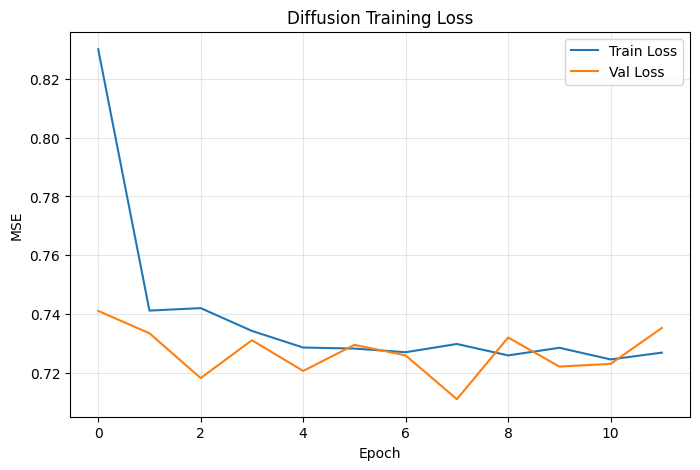

In [12]:
# =========================================================
# CELL 10 — Plot Training Curves
# =========================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Diffusion Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11.VISUALIZATION OF FORWARD NOISING PROCESS


###11.1.OVERVIEW

**Cell 11 Explanation**

This cell visualizes the forward noising process on a single example sequence. It takes one validation sample and shows how that sample looks after different amounts of diffusion noise have been applied. This is one of the most intuitive cells in the notebook because it makes the abstract corruption process directly visible.

At very early timesteps, the noisy sequence still resembles the original quite closely. As the timestep increases, more of the original structure is obscured. By the late stages, the sample may look largely random, with only weak traces of the original pattern remaining. This gradual degradation is the key to the diffusion framework. The model’s job is to learn how to reverse this process.

Pedagogically, this cell is especially valuable because students often understand equations more deeply once they see them in action. The forward process may be mathematically compact, but its significance becomes clearer when one observes actual sequences becoming progressively noisier. The visualization turns the timetable of corruption into a concrete object.

This cell also helps set expectations for the denoiser. If the forward process destroys almost all recognizable structure at large timesteps, then the reverse model must be quite skillful to reconstruct plausible samples starting from near-random noise. The plot therefore makes the generation challenge feel real rather than merely theoretical.

More broadly, this cell teaches a principle that is useful well beyond diffusion: whenever possible, visualize the transformations your model relies on. Doing so makes debugging easier, strengthens intuition, and helps ensure that the implemented process matches the intended design.

###11.2.CODE AND IMPLEMENTATION

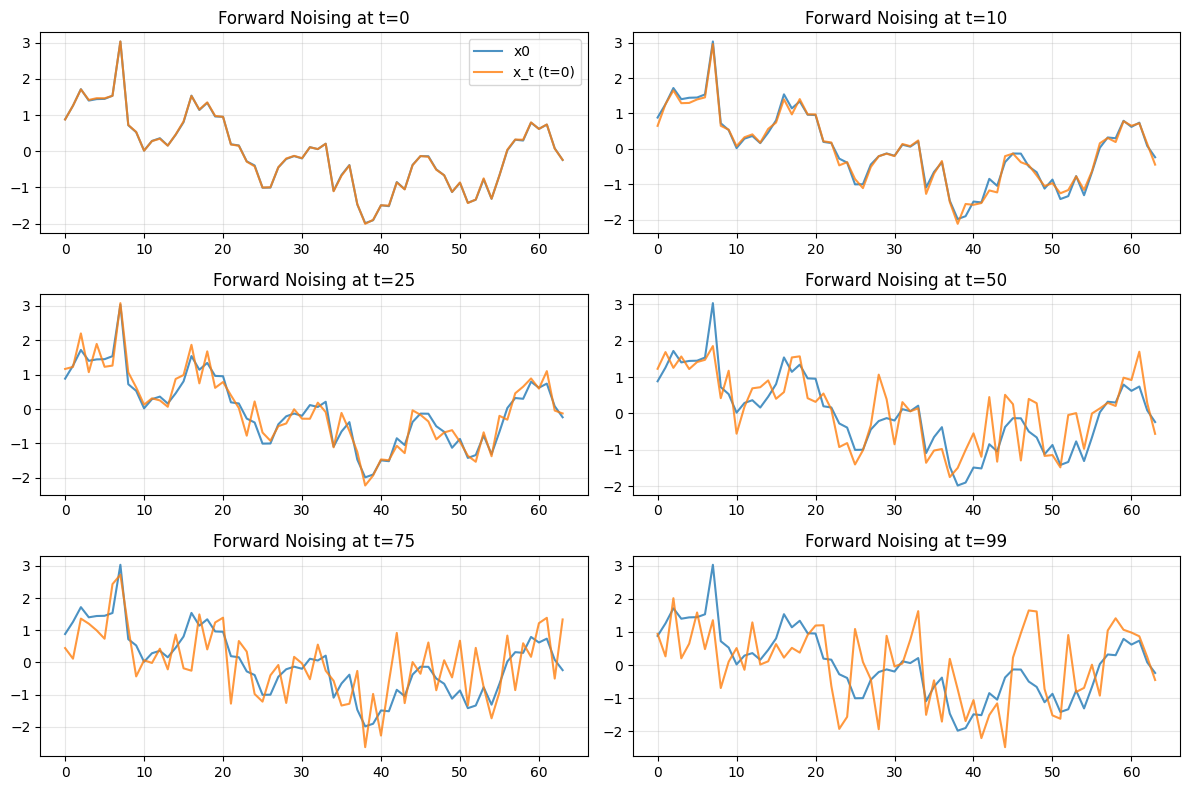

In [13]:
# =========================================================
# CELL 11 — Visualize Forward Noising Process
# =========================================================

model.eval()

x_example = next(iter(val_loader))[:1].to(device)  # [1, L, 1]
timesteps_to_show = [0, 10, 25, 50, 75, 99]

plt.figure(figsize=(12, 8))
for i, t_val in enumerate(timesteps_to_show, 1):
    t = torch.tensor([t_val], device=device)
    xt = q_sample(x_example, t)

    plt.subplot(3, 2, i)
    plt.plot(x_example[0, :, 0].detach().cpu().numpy(), label="x0", alpha=0.8)
    plt.plot(xt[0, :, 0].detach().cpu().numpy(), label=f"x_t (t={t_val})", alpha=0.8)
    plt.title(f"Forward Noising at t={t_val}")
    plt.grid(True, alpha=0.3)
    if i == 1:
        plt.legend()

plt.tight_layout()
plt.show()

##12.REVERSE SAMPLING

###12.1.OVERVIEW

**Cell 12 Explanation**

This cell defines the reverse sampling process. Earlier cells taught the model how to predict noise given a noisy sequence and a timestep. This cell uses that learned ability to generate new synthetic sequences. In a diffusion model, sampling means starting from random noise and then repeatedly applying denoising steps until a structured sample emerges.

The first function performs one reverse step. It uses the current noisy input, the timestep, and the model’s noise prediction to compute a mean for the next, slightly cleaner state. If the process has not yet reached the final step, the function also adds a controlled amount of randomness through the posterior variance term. This preserves the stochastic nature of the generation process.

The second function runs the full sampling loop. It begins with pure Gaussian noise and then moves backward through the diffusion steps one by one. At selected stages, it saves intermediate states so that the denoising trajectory can later be visualized. This is useful because generation in diffusion is not a single jump from randomness to structure. It is a gradual refinement process.

Pedagogically, this cell is central because it answers the student’s natural question: once the model has been trained, how do we actually generate something new? The answer is that training taught the model a local denoising rule, and sampling applies that rule repeatedly. This is the operational meaning of generation in diffusion.

This cell also illustrates an important theme of the notebook: the same learned denoiser is reused across many stages of the reverse process. The model is not memorizing complete samples. It is learning how to make locally informed corrections under different noise conditions.

###12.2.CODE AND IMPLEMENTATION

In [14]:
# =========================================================
# CELL 12 — Reverse Sampling
# =========================================================
# Standard ancestral DDPM-style sampling.

@torch.no_grad()
def p_sample(model, x, t):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_ab_t = extract(sqrt_one_minus_alpha_bars, t, x.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x.shape)

    eps_theta = model(x, t)

    model_mean = sqrt_recip_alpha_t * (
        x - betas_t * eps_theta / sqrt_one_minus_ab_t
    )

    posterior_var_t = extract(posterior_variance, t, x.shape)

    nonzero_mask = (t != 0).float().view(x.size(0), 1, 1)
    noise = torch.randn_like(x)
    return model_mean + nonzero_mask * torch.sqrt(torch.clamp(posterior_var_t, min=1e-20)) * noise

@torch.no_grad()
def sample_sequences(model, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, cfg.seq_len, 1, device=device)

    trajectory = []
    for step in reversed(range(cfg.diffusion_steps)):
        t = torch.full((n_samples,), step, device=device, dtype=torch.long)
        x = p_sample(model, x, t)
        if step in [99, 75, 50, 25, 10, 0]:
            trajectory.append((step, x.detach().cpu().numpy()))
    return x.detach().cpu().numpy(), trajectory

samples, trajectory = sample_sequences(model, n_samples=12)
print("Generated samples shape:", samples.shape)

Generated samples shape: (12, 64, 1)


##13.VISUALIZATION OF GENERATED SYNTHETIC RETURN PATHS

###13.1.OVERVIEW

**Cell 13 Explanation**

This cell plots the synthetic return paths generated by the trained diffusion model. After the model has completed the reverse sampling process, the resulting sequences are visualized together so that the learner can inspect their shapes, variation, and overall plausibility. This is one of the first moments in the notebook where the model’s generative ability becomes directly visible.

The value of this cell lies in qualitative interpretation. The student can ask whether the generated paths look structured rather than purely random, whether different samples display diversity, and whether the outputs resemble the general style of the synthetic training data. In a successful run, the sequences should not all look identical, and they should not collapse into trivial flat patterns. Instead, they should exhibit variation in oscillation, local movement, and overall shape.

Pedagogically, this cell teaches that generated samples are an important but incomplete form of evaluation. Looking at several outputs together can reveal obvious pathologies such as repetition, instability, or unrealistic amplitude. It also helps the learner appreciate that generative models produce distributions, not single canonical answers. The question is not whether one path is perfect. The question is whether the collection of generated paths appears to come from the same broad family as the reference data.

This cell is also satisfying from an educational standpoint because it shows the payoff of the previous steps. The notebook began with mathematical schedules, embeddings, and training losses. Here, those abstract components produce visible synthetic financial trajectories. This moment helps students connect the theory to a tangible result.

###13.2.CODE AND IMPLEMENTATION

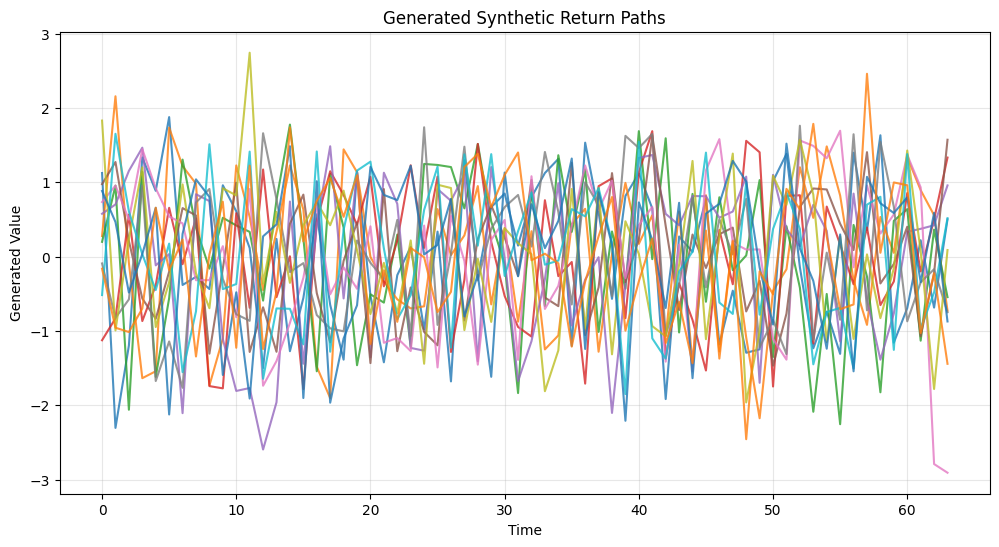

In [15]:
# =========================================================
# CELL 13 — Visualize Generated Synthetic Return Paths
# =========================================================

plt.figure(figsize=(12, 6))
for i in range(len(samples)):
    plt.plot(samples[i, :, 0], alpha=0.8)
plt.title("Generated Synthetic Return Paths")
plt.xlabel("Time")
plt.ylabel("Generated Value")
plt.grid(True, alpha=0.3)
plt.show()

##14.COMPARISON OF REAL AND SYNTHETIC DISTRIBUTIONS

###14.1.OVERVIEW

**Cell 14 Explanation**

This cell compares the distribution of values in the generated samples with the distribution of values in the reference validation data. Instead of looking only at entire paths visually, the notebook now performs a simple statistical comparison using histograms. This adds another layer of evaluation.

The cell first flattens both datasets so that all sequence values are collected into one-dimensional arrays. It then plots density histograms for the real synthetic data and the generated data on the same axes. If the model has learned reasonably well, the two distributions should show at least some broad resemblance. They may not match perfectly, especially in a small educational notebook, but this plot gives a useful first diagnostic.

Pedagogically, this cell teaches that generative modeling should be evaluated from more than one angle. Visual inspection of sample paths is informative, but it can be misleading if used alone. A model might generate paths that look plausible individually while still failing to reproduce the correct marginal distribution. By comparing histograms, the notebook encourages a more disciplined habit of checking statistical properties as well as appearance.

This cell also introduces the idea that there are many possible levels of evaluation. A histogram is a simple starting point. In more advanced work, one might examine autocorrelation, volatility clustering, tail behavior, pathwise moments, or dependence structure across variables. But for a first notebook, the histogram is a clear and accessible demonstration that generated outputs should be judged against reference statistics, not just by eye.

###14.2.CODE AND IMPLEMENTATION

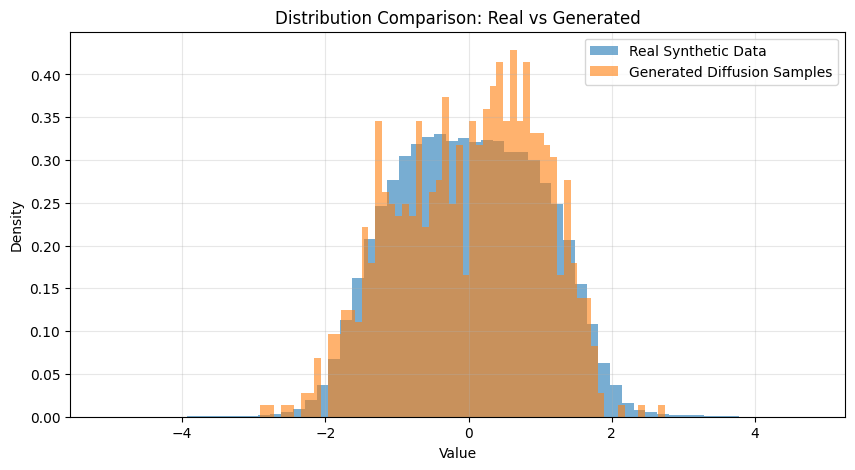

In [16]:
# =========================================================
# CELL 14 — Compare Real vs Generated Distribution
# =========================================================

real_flat = val_data.reshape(-1)
gen_flat = samples.reshape(-1)

plt.figure(figsize=(10, 5))
plt.hist(real_flat, bins=60, alpha=0.6, density=True, label="Real Synthetic Data")
plt.hist(gen_flat, bins=60, alpha=0.6, density=True, label="Generated Diffusion Samples")
plt.title("Distribution Comparison: Real vs Generated")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##15.DENOISING TRAJECTORY VISUALIZATION

###15.1.OVEVIEW

**Cell 15 Explanation**

This final cell visualizes the denoising trajectory during reverse sampling. Instead of showing only the final generated sample, it displays intermediate states captured at selected timesteps as the model transforms noise into structure. This is an especially pedagogical ending because it reveals generation as a process rather than as a finished object.

Each subplot corresponds to one stage of the reverse chain. Early states are usually quite noisy and poorly structured. As the process moves forward, patterns begin to emerge. By the final stage, the sequence should look substantially more organized and closer to the kind of data the model was trained on. This makes the iterative nature of diffusion very clear. The model does not invent the final answer all at once. It gradually refines a rough noisy initialization.

Pedagogically, this cell is powerful because it helps students build intuition about what the reverse process is doing at each step. Diffusion can feel abstract when described only as a Markov chain or a denoising procedure. Seeing the path evolve stage by stage makes the concept concrete. It also reinforces the idea that sampling quality depends on the repeated success of many local denoising steps.

This cell serves as a fitting conclusion to the notebook because it brings together the central theme of the entire exercise: generation as iterative reconstruction from noise. The learner can now see the full arc of the model. The notebook started with clean data, corrupted those data through the forward process, trained a denoiser to predict the corruption, and then used that denoiser to reverse noise into plausible structure. The trajectory plot is therefore more than a visualization. It is a summary of the notebook’s core logic.

###15.2.CODE AND IMPLEMENTATION

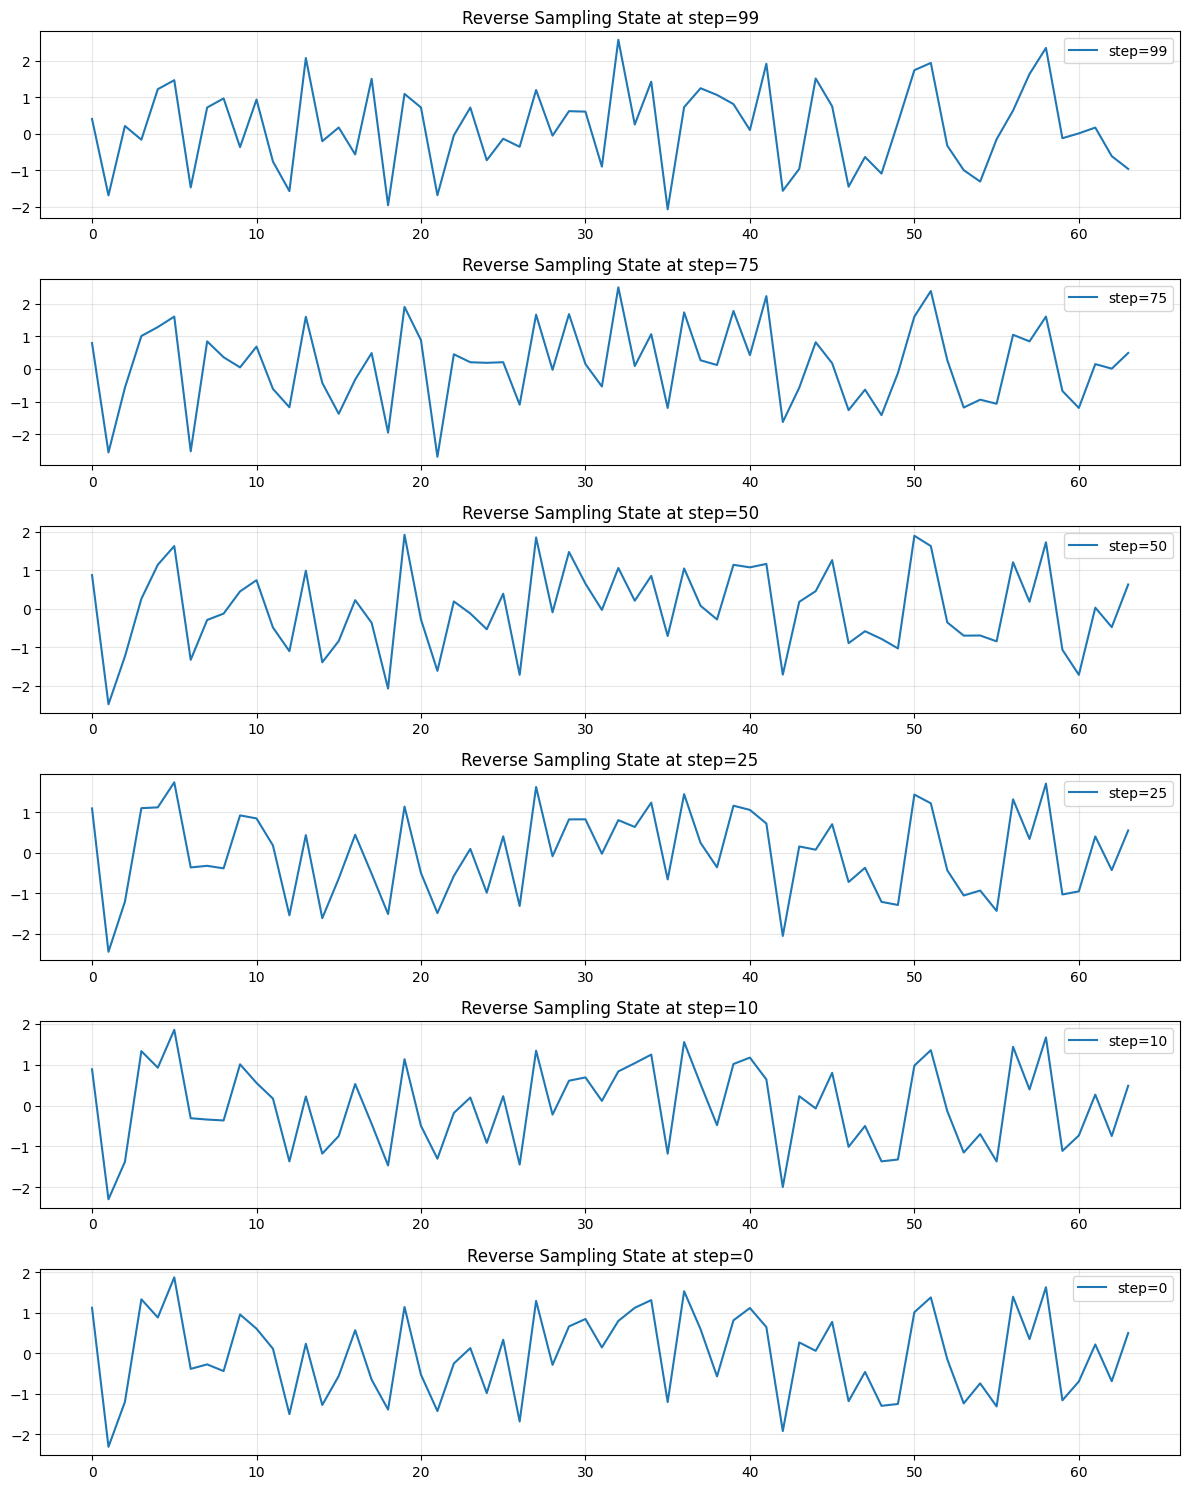

In [17]:
# =========================================================
# CELL 15 — Denoising Trajectory Visualization
# =========================================================

fig, axes = plt.subplots(len(trajectory), 1, figsize=(12, 2.5 * len(trajectory)))

if len(trajectory) == 1:
    axes = [axes]

for ax, (step, arr) in zip(axes, trajectory):
    ax.plot(arr[0, :, 0], label=f"step={step}")
    ax.set_title(f"Reverse Sampling State at step={step}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

##16.CONCLUSIONS

**Conclusion**

This notebook has taken a deliberately careful and pedagogical path through the mechanics of diffusion modeling in a financial setting. Rather than beginning with the full complexity of contemporary large-scale generative systems, it focused on a minimal but meaningful example: synthetic financial time series, a Gaussian forward process, a compact transformer denoiser, and a reverse sampling mechanism that reconstructs structured paths from noise. That path matters because diffusion models are often introduced through highly polished image generation systems or through mathematically dense papers that can make the topic appear more mysterious than it really is. This notebook has tried to do the opposite. It has treated diffusion as an intelligible modeling process that can be unpacked step by step, visualized directly, and connected to problems that financial practitioners can immediately recognize.

The first major lesson is that diffusion is best understood as a supervised learning problem disguised as generation. This is a useful mental model for students encountering the topic for the first time. The model is not asked to produce a realistic return path in a single jump. Instead, it is shown a clean sequence, a noisy version of that sequence, and the timestep describing the degree of corruption. It then learns to predict the noise component. This formulation is powerful because it transforms generative modeling into a large collection of local denoising tasks. Each task is relatively manageable, but taken together they teach the model how structured data differ from pure randomness. When these local lessons are chained across the full diffusion process, generation emerges.

The second major lesson is that the forward process is not just a mathematical convenience. It is a way of defining what it means to gradually forget structure. In finance, this idea has intuitive resonance. Markets are full of partial information, latent patterns, and noisy realizations. Analysts constantly try to separate persistent signal from transient disturbance. The diffusion framework formalizes an analogous idea. At early timesteps, the clean sequence is still mostly visible. At late timesteps, noise dominates. The denoiser is therefore learning a kind of statistical reconstruction skill: given a sequence at a known level of degradation, infer how much of its structure can still be recovered. Even in a synthetic example, this logic mirrors an important intellectual habit in financial modeling, namely the disciplined distinction between what is informative and what is spurious.

A third lesson concerns architecture. The notebook used a transformer rather than a convolutional image model. This choice is conceptually significant. It demonstrates that diffusion is not wedded to one particular neural network family. The same probabilistic framework can be paired with different denoising backbones depending on the nature of the data. For one-dimensional sequences, a transformer is especially instructive because it encourages the learner to think about denoising as a sequence understanding task. Attention allows the model to examine relationships across time positions, integrate global context, and reconstruct coherent patterns even when observations are noisy. This becomes particularly relevant when one looks ahead to discrete sequence diffusion, masked token processes, tabular generation, or finance-related text modeling. The notebook therefore serves not only as an introduction to diffusion, but also as an introduction to the broader portability of the diffusion idea.

The synthetic data design also carried an important educational message. The notebook did not pretend that artificial sine-like return paths are substitutes for real markets. They are not. Real financial systems contain far richer dependence structures, regime shifts, nonstationarities, institutional frictions, behavioral components, and structural breaks. Yet synthetic data are extremely useful at the learning stage because they isolate mechanism from noise in the broader pedagogical sense. When the learner sees the model reconstruct paths that include oscillation, trend, volatility variation, and occasional shocks, the essential question becomes clear: has the model learned the structure of the data-generating environment well enough to reproduce its statistical character? That is the right first question. Only later should one introduce the more difficult questions of realism, robustness, and institutional deployment.

The training process and the associated visual diagnostics provide another important takeaway. Generative models are often discussed in abstract terms, but this notebook insists on observable behavior. Training curves help determine whether learning is actually occurring. Forward noising plots show how the corruption schedule behaves in practice rather than merely in equations. Reverse sampling plots make the generation process visible as a trajectory rather than as a black box. Histograms comparing real and generated values offer a simple but useful distributional check. These diagnostics matter because a good generative modeling workflow should never rely only on the fact that code executes without error. One must inspect what the model is learning, how it is learning, and whether the outputs make sense relative to the intended statistical environment.

From a finance perspective, the notebook also points toward a set of important applications. A trained diffusion model on returns can be viewed as a scenario generator. It can provide synthetic price paths for stress testing, simulation, and educational backtesting environments. With conditioning mechanisms, one could extend the same logic toward crash scenarios, rally scenarios, or volatility-conditioned paths. With modified architectures, diffusion can be applied to tabular synthesis for portfolio records or trade features, to imputation for missing risk factors, and to discrete regime modeling through masked token diffusion. These applications should be approached carefully and with proper governance, but the core idea is already present in this notebook: diffusion is a flexible generator of structured uncertainty.

Another important conclusion is that the notebook acts as a bridge between continuous and discrete generative thinking. Here the model works with Gaussian noise over continuous-valued sequences. That is the classical point of entry because the mathematics is clean and the visualizations are intuitive. But in many modern sequence problems, especially in language-related applications, data are discrete. One cannot simply add Gaussian noise to token identities in the same way. This is why masked diffusion, absorbing-state processes, and embedding-based formulations have become so important. By learning the continuous case first, the student acquires the conceptual vocabulary needed to understand the discrete case later. The denoiser, the timestep conditioning, the gradual corruption process, and the iterative reconstruction logic all carry over, even if the technical details change.

It is also worth emphasizing what this notebook does not do. It does not establish that diffusion models are universally superior to autoregressive methods in finance. It does not prove that synthetic time-series generation from small neural models will be useful for production trading systems. It does not solve the many challenges of evaluating financial generative models under real-world constraints. Those challenges include calibration, tail behavior, dependence preservation, regime realism, governance, and misuse risk. A responsible conclusion must acknowledge these boundaries. The notebook is an educational laboratory, not a production framework. Its success should be measured by the quality of the learner’s understanding, not by inflated claims about immediate deployment.

That said, the educational value is substantial. A student who has worked carefully through these cells should now understand the diffusion workflow from end to end. They should understand why the model needs a noise schedule, why timestep embeddings are necessary, why the denoiser predicts noise rather than directly reconstructing clean data in the training objective, and how reverse sampling iteratively transforms random initialization into structured sequences. They should also appreciate that the visual outputs are not decorative extras, but part of the reasoning toolkit for interpreting generative models.

Looking forward, the most natural next steps are threefold. First, one can extend the notebook to masked diffusion over discrete regime tokens, which brings the framework closer to sequence generation and language-style modeling. Second, one can introduce conditioning variables so that generation is guided by desired scenario labels or exogenous states. Third, one can deepen the evaluation framework by adding summary statistics, autocorrelation checks, volatility clustering comparisons, or distributional distances between real and generated samples. Each of these steps would move the project from a foundational teaching notebook toward a richer research laboratory.

In the end, the central achievement of this notebook is conceptual clarity. It shows that diffusion is not magic. It is an organized way of teaching a model how to reconstruct structure from noise. For finance, that idea is more than technically fashionable. It is philosophically fitting. Financial modeling has always involved extracting meaningful patterns from environments dominated by uncertainty, partial observability, and randomness. Diffusion models place that struggle directly at the center of the generative process. By starting with a small, synthetic, transparent example, the notebook creates a disciplined foundation from which more advanced applications can later grow. That foundation is the real purpose of the exercise, and it is the right place to begin.